# Exercise 01: Regression and Classification

This notebook combines the linear regression and logistic regression exercises into one runnable workflow.

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(42)

## Task 2: Linear Regression with PyTorch

Learning objectives:
- Get familiar with PyTorch tensors and basic linear algebra operations
- Implement the closed-form (normal equation) solution for linear regression
- Visualize data and the fitted regression line

In [5]:
def closed_form_solution(x, y):
    """Compute optimal [slope, intercept] via the normal equation."""
    ones = torch.ones_like(x)
    X = torch.stack((x, ones), dim=1)
    theta = torch.linalg.inv(X.T @ X) @ X.T @ y
    return theta

Estimated slope: 2.9971
Estimated intercept: 2.0892


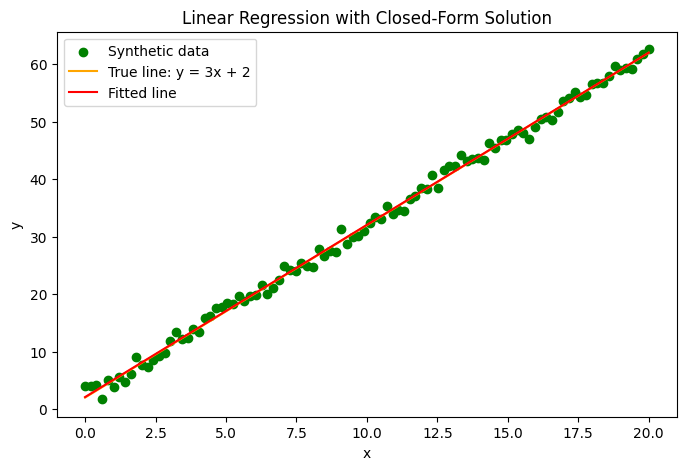

In [6]:
N = 100
x = torch.linspace(0, 20, N)
eps = torch.randn(N)
y = 3 * x + 2 + eps

theta = closed_form_solution(x, y)
y_fitted = theta[0] * x + theta[1]

print(f"Estimated slope: {theta[0].item():.4f}")
print(f"Estimated intercept: {theta[1].item():.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="green", label="Synthetic data")
plt.plot(x, 3 * x + 2, color="orange", label="True line: y = 3x + 2")
plt.plot(x, y_fitted, color="red", label="Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression with Closed-Form Solution")
plt.legend()
plt.show()

## Task 3: Logistic Regression with PyTorch

Learning objectives:
- Implement sigmoid and binary cross-entropy using PyTorch tensors
- Train a binary classifier using gradient descent
- Visualize decision boundaries

In [7]:
def sigmoid(z):
    """Numerically stable sigmoid function."""
    return torch.where(
        z >= 0,
        1 / (1 + torch.exp(-z)),
        torch.exp(z) / (1 + torch.exp(z)),
    )


def softmax(z):
    """Numerically stable softmax. z has shape (N, K)."""
    max_z = torch.max(z, dim=1, keepdim=True).values
    z_shifted = z - max_z
    exp_z_shifted = torch.exp(z_shifted)
    sum_exp_z_shifted = torch.sum(exp_z_shifted, dim=1, keepdim=True)
    return exp_z_shifted / sum_exp_z_shifted


def binary_cross_entropy(y_true, y_pred):
    """Compute the mean binary cross-entropy loss."""
    term_1 = y_true * torch.log(y_pred)
    term_2 = (1 - y_true) * torch.log(1 - y_pred)
    return -torch.mean(term_1 + term_2)


def logistic_regression_train(X_train, y_train, lr=0.1, n_iterations=1000):
    """Train binary logistic regression using gradient descent."""
    _, D = X_train.shape
    w = torch.zeros(D, requires_grad=True)
    b = torch.tensor(0.0, requires_grad=True)
    losses = []

    for _ in range(n_iterations):
        y_pred = sigmoid(X_train @ w + b)
        loss = binary_cross_entropy(y_train, y_pred)
        losses.append(loss.item())

        loss.backward()

        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad

        w.grad.zero_()
        b.grad.zero_()

    return w, b, losses


def predict(X, w, b, threshold=0.5):
    """Predict class labels."""
    y_pred = sigmoid(X @ w + b)
    return torch.where(y_pred > threshold, 1, 0)


def plot_decision_boundary(X, y, w, b):
    """Plot data points and the linear decision boundary."""
    X_np = X.detach().cpu().numpy() if isinstance(X, torch.Tensor) else X
    y_np = y.detach().cpu().numpy() if isinstance(y, torch.Tensor) else y
    w_np = w.detach().cpu().numpy() if isinstance(w, torch.Tensor) else w
    b_np = b.item() if isinstance(b, torch.Tensor) else b

    plt.figure(figsize=(8, 5))
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap="bwr", alpha=0.6, edgecolors="k")

    x1_min, x1_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    x1_values = np.linspace(x1_min, x1_max, 100)
    x2_values = -(w_np[0] * x1_values + b_np) / w_np[1]

    plt.plot(x1_values, x2_values, color="black", lw=2, label="Decision Boundary")
    plt.title("Logistic Regression Decision Boundary")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()
    plt.show()

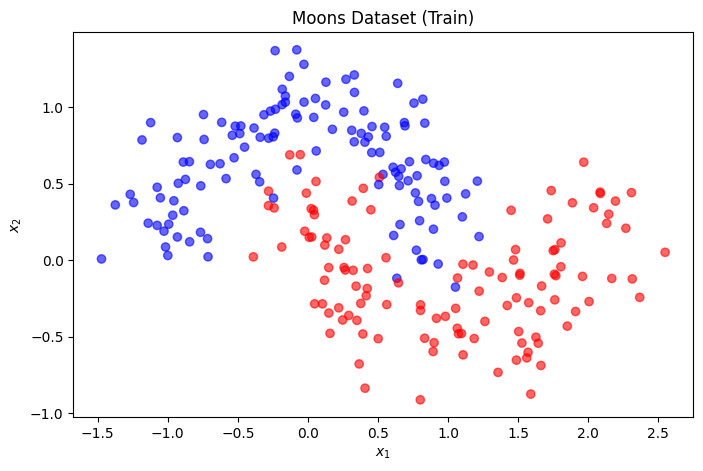

Train accuracy: 0.8541666865348816
Test accuracy: 0.8999999761581421


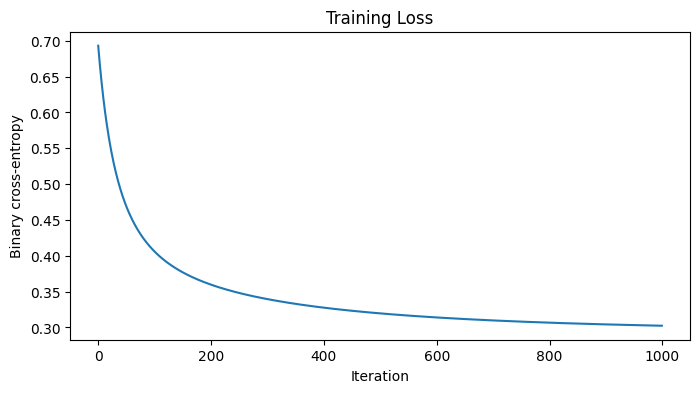

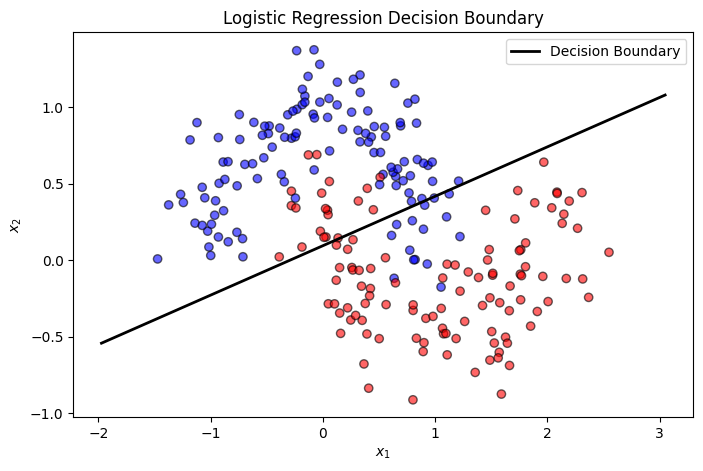

In [8]:
X_np, y_np = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="bwr", alpha=0.6)
plt.title("Moons Dataset (Train)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

w, b, losses = logistic_regression_train(X_train, y_train)

y_train_pred = predict(X_train, w, b)
y_test_pred = predict(X_test, w, b)

train_acc = (y_train_pred == y_train).float().mean()
test_acc = (y_test_pred == y_test).float().mean()

print("Train accuracy:", train_acc.item())
print("Test accuracy:", test_acc.item())

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy")
plt.show()

plot_decision_boundary(X_train, y_train, w, b)

### Reflection

The moons dataset is not linearly separable, so logistic regression with a linear decision boundary cannot fully capture its curved structure. A polynomial feature mapping or a more expressive model would fit this data better.